### Cancellation model experiments
* run on the synthetic booking stream, bookings made up to today with a known outcome
* protocol: training cohorts, a time based validation cohort for early stopping, calibration and every selection, and out of time test sets touched only for the final table
* steps: audit of the new guest and account features, leakage audit of the stream, feature set and window, outlier treatment, scaling, hybrid stepwise selection, hyperparameter search with a regularisation loop, the feature sets again under the tuned parameters, class weights, model families and a stack, calibration
* selection by a reliability rule: lowest validation log loss with the train against validation gap within a limit, rather than the highest auc
* results table and the chosen setup printed at the end, exported for the models dashboard
* quick mode: the same protocol with the most informative candidates only, two windows, two outlier treatments, one scaler, the stepwise selection against the gain pruned and the full set, eight search configurations, the boosted model against logistic regression; the full grid ran on the stream of 25 September 2026

#### Validation protocol
* snapshot S is 90 days ago, every arrival before S has a known outcome
* training pool: arrival cohorts up to 120 days before S, validation: arrivals in the 120 days before S, split by booking before landmark sampling
* category levels, medians, percentiles and scalers are fit on training rows only, the calibrator on validation rows only
* test sets: bookings on the books at S with arrival within 90 days scored as of S, arrivals in the 8 weeks after S scored at booking time, bookings made after S with a known outcome (biased toward short lead times)
* outcomes not revealed by today never enter any set
* leakage audit: the outcome of the real atom behind each synthetic booking must not predict the synthetic outcome, and copies of one atom must differ in their features

In [1]:
import os
import sys
import json
import time
import datetime
import warnings
import numpy as np
import pandas as pd
import lightgbm as lgb
import statsmodels.api as sm
import matplotlib.pyplot as plt
from sklearn.pipeline import Pipeline
from catboost import CatBoostClassifier
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.isotonic import IsotonicRegression
from sklearn.neural_network import MLPClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import OneHotEncoder, StandardScaler, RobustScaler, QuantileTransformer
from sklearn.metrics import roc_auc_score, average_precision_score, brier_score_loss, log_loss
warnings.filterwarnings("ignore")

In [2]:
ROOT_DIR = os.path.abspath(os.path.join(os.getcwd(), ".."))
sys.path.insert(0, ROOT_DIR)

from app.models import context
from app.models import features

In [3]:
# paths and protocol parameters
PARQUET_PATH = os.path.join(ROOT_DIR, "data", "parquet", "bookings.parquet")
WEATHER_PATH = os.path.join(ROOT_DIR, "data", "parquet", "weather.parquet")
HOLIDAYS_PATH = os.path.join(ROOT_DIR, "data", "parquet", "holidays.parquet")
MODELS_DIR = os.path.join(ROOT_DIR, "data", "models")
today = pd.Timestamp(datetime.date.today())
snapshot = today - pd.Timedelta(days=90)
valid_days = 120
near_days = 56
windows = {"all": None, "5 years": 5, "3 years": 3, "2 years": 2, "1 year": 1}
threads = 3
rng = np.random.default_rng(7)
fast_params = {"objective": "binary", "metric": ["binary_logloss", "auc"], "learning_rate": 0.1, "num_leaves": 31, "min_data_in_leaf": 100, "feature_fraction": 0.8, "bagging_fraction": 0.8, "bagging_freq": 1, "lambda_l2": 5.0, "verbose": -1, "num_threads": threads, "seed": 7}
base_params = {"objective": "binary", "metric": ["binary_logloss", "auc"], "learning_rate": 0.05, "num_leaves": 31, "min_data_in_leaf": 300, "feature_fraction": 0.6, "bagging_fraction": 0.8, "bagging_freq": 1, "lambda_l2": 30.0, "cat_smooth": 100.0, "verbose": -1, "num_threads": threads, "seed": 7}
v1_params = {"objective": "binary", "metric": ["binary_logloss", "auc"], "learning_rate": 0.02, "num_leaves": 255, "min_data_in_leaf": 80, "feature_fraction": 0.7, "bagging_fraction": 0.8, "bagging_freq": 1, "lambda_l2": 3.0, "min_gain_to_split": 0.01, "verbose": -1, "num_threads": threads, "seed": 7}
clip_low = 0.005
clip_high = 0.99
gap_limit = 0.03
quick = True
champion_features = ["deposit_type", "survived_share", "agent", "country", "lead_time", "prev_cancel_ratio", "required_car_parking_spaces", "customer_type", "total_of_special_requests"]
if quick:
    windows = {"all": None, "3 years": 3}

#### Data and splits

In [4]:
# load the stream export with typed dates, rate cleaning and the outcome mask, only the columns the features and the splits need
def load_bookings(path):
    keep = ["booking_id", "source_booking_id", "hotel", "is_canceled", "lead_time", "arrival_date", "booking_date", "leave_books_date", "nights", "stays_in_weekend_nights", "stays_in_week_nights", "adults", "children", "babies", "meal", "country", "market_segment", "distribution_channel", "is_repeated_guest", "previous_cancellations", "previous_bookings_not_canceled", "reserved_room_type", "deposit_type", "agent", "company", "days_in_waiting_list", "customer_type", "adr", "required_car_parking_spaces", "total_of_special_requests", "same_day_clones", "agent_prior_rate", "agent_prior_n", "country_prior_rate", "company_prior_rate", "company_prior_n", "agent_recency_days", "agent_prior_365", "agent_avg_lead_365", "agent_avg_adr_365", "country_prior_365", "hotel_prior_365", "outcome_known"]
    frame = pd.read_parquet(path, columns=keep)
    for col in ["arrival_date", "booking_date", "leave_books_date"]:
        frame[col] = pd.to_datetime(frame[col])
    for col in ["hotel", "meal", "country", "market_segment", "distribution_channel", "reserved_room_type", "deposit_type", "agent", "company", "customer_type"]:
        frame[col] = frame[col].astype("category")
    frame = frame[(frame["adr"] >= 0) & (frame["adr"] < 1000)]
    frame["outcome_known"] = frame["outcome_known"].astype(bool)
    return frame.reset_index(drop=True)

In [5]:
# training pool, validation cohort and the three test sets, every set with a known outcome; the on the books set keeps arrivals within 90 days of the snapshot so that both outcomes are observable
def split_cohorts(frame):
    known = frame[frame["outcome_known"]].copy()
    known["is_canceled"] = known["is_canceled"].astype(int)
    train_end = snapshot - pd.Timedelta(days=valid_days)
    out = {}
    out["train_pool"] = known[known["arrival_date"] <= train_end]
    out["valid"] = known[(known["arrival_date"] > train_end) & (known["arrival_date"] <= snapshot)]
    out["on_books"] = known[(known["booking_date"] <= snapshot) & (known["leave_books_date"] > snapshot) & (known["arrival_date"] > snapshot) & (known["arrival_date"] <= snapshot + pd.Timedelta(days=90))]
    out["near"] = known[(known["arrival_date"] > snapshot) & (known["arrival_date"] <= snapshot + pd.Timedelta(days=near_days))]
    out["future"] = known[known["booking_date"] > snapshot]
    return out

In [6]:
# training rows of a window, arrival cohorts of the last years before the training end
def window_rows(train_pool, years):
    if years is None:
        return train_pool
    start = snapshot - pd.Timedelta(days=valid_days) - pd.DateOffset(years=years)
    return train_pool[train_pool["arrival_date"] > start]

In [7]:
# expand bookings into as of observations at random dates between booking and departure from the books
def landmark(frame, k, seed):
    gen = np.random.default_rng(seed)
    parts = []
    for i in range(k):
        out = frame.copy()
        span = (out["leave_books_date"].clip(upper=out["arrival_date"]) - out["booking_date"]).dt.days.clip(lower=0)
        offset = np.floor(gen.random(len(out)) * (span.values + 1))
        out["as_of"] = out["booking_date"] + pd.to_timedelta(offset, unit="D")
        parts.append(out)
    return pd.concat(parts, ignore_index=True)

In [8]:
# observe a frame at one fixed date or at each row's booking date
def observe_at(frame, date):
    out = frame.copy()
    out["as_of"] = date
    return out

In [9]:
bookings = load_bookings(PARQUET_PATH)
weather = pd.read_parquet(WEATHER_PATH)
holidays = pd.read_parquet(HOLIDAYS_PATH)
cohorts = split_cohorts(bookings)
raw_agents = bookings.loc[bookings["agent"].astype(str) != "NULL", ["agent", "booking_date", "agent_prior_365"]].copy()
del bookings
print("snapshot " + str(snapshot.date()) + ", training cohorts up to " + str((snapshot - pd.Timedelta(days=valid_days)).date()))
for name, part in cohorts.items():
    print(name + ": rows " + str(len(part)) + ", cancel rate " + str(round(float(part["is_canceled"].mean()), 4)) + ", arrivals " + str(part["arrival_date"].min().date()) + " to " + str(part["arrival_date"].max().date()))
test_sets = {"on_books": context.add_context(observe_at(cohorts["on_books"], snapshot), weather, holidays), "near": context.add_context(observe_at(cohorts["near"], cohorts["near"]["booking_date"]), weather, holidays), "future": context.add_context(observe_at(cohorts["future"], cohorts["future"]["booking_date"]), weather, holidays)}
valid_k1 = context.add_context(landmark(cohorts["valid"], 1, 11), weather, holidays)

snapshot 2026-06-27, training cohorts up to 2026-02-27
train_pool: rows 630664, cancel rate 0.2764, arrivals 2014-01-06 to 2026-02-27
valid: rows 23259, cancel rate 0.3082, arrivals 2026-02-28 to 2026-06-27
on_books: rows 8364, cancel rate 0.207, arrivals 2026-06-28 to 2027-08-11
near: rows 9212, cancel rate 0.3302, arrivals 2026-06-28 to 2026-08-22
future: rows 5406, cancel rate 0.3873, arrivals 2026-06-28 to 2027-10-24


#### New feature audit
* distributions, power against the target and redundancy of the guest and account features added with the second feature set
* as of check: the account features are recomputed from the booking's own past on a sample and compared with the stored values

In [10]:
# feature matrix with the labels for a frame, levels learned on the training frame
def matrix(frame, levels, cols):
    x = features.transform(frame, levels)
    return x[cols]

In [11]:
# univariate power of numeric features against the target, roc auc of the raw value oriented above 0.5, and the correlation
def numeric_power(x, y, cols):
    rows = []
    for col in cols:
        v = pd.to_numeric(x[col], errors="coerce").fillna(0).values
        if v.std() == 0:
            rows.append({"feature": col, "auc": 0.5, "corr": 0.0})
            continue
        auc = roc_auc_score(y, v)
        rows.append({"feature": col, "auc": round(max(auc, 1 - auc), 4), "corr": round(float(np.corrcoef(v, y)[0, 1]), 3)})
    return pd.DataFrame(rows).sort_values("auc", ascending=False)

In [12]:
# largest absolute correlation of every new feature with any feature of the first set
def redundancy(x, new_cols, old_cols):
    corr = x[new_cols + old_cols].apply(pd.to_numeric, errors="coerce").corr()
    rows = []
    for col in new_cols:
        partner = corr.loc[col, old_cols].abs().sort_values(ascending=False)
        rows.append({"feature": col, "closest_v1_feature": partner.index[0], "abs_corr": round(float(partner.iloc[0]), 3)})
    return pd.DataFrame(rows).sort_values("abs_corr", ascending=False)

In [13]:
# as of audit of the account features on a sample, recomputed from bookings made before each booking
def as_of_audit(frame, sample_size=400):
    sample = frame.sample(sample_size, random_state=7)
    mismatches = 0
    for r in sample.itertuples(index=False):
        past = frame[(frame["agent"].astype(str) == str(r.agent)) & (frame["booking_date"] < r.booking_date) & (frame["booking_date"] >= r.booking_date - pd.Timedelta(days=365))]
        if int(len(past)) != int(r.agent_prior_365):
            mismatches = mismatches + 1
    return mismatches

In [14]:
# histogram grid of the new features on the training pool
def plot_new_features(x, cols, ncols=6):
    nrows = int(np.ceil(len(cols) / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(3.2 * ncols, 2.6 * nrows))
    for ax, col in zip(np.ravel(axes), cols):
        v = pd.to_numeric(x[col], errors="coerce").dropna()
        if set(pd.unique(v)) <= {0, 1}:
            counts = v.value_counts().reindex([0, 1]).fillna(0)
            ax.bar(["0", "1"], counts.values, color=["gray", "steelblue"], edgecolor="black", linewidth=0.5)
        else:
            ax.hist(v.clip(upper=v.quantile(0.995)), bins=40, color="steelblue", edgecolor="black", linewidth=0.3)
        ax.set_title(col, fontsize=10)
    for ax in np.ravel(axes)[len(cols):]:
        ax.axis("off")
    plt.tight_layout()
    plt.show()

training pool of the last 3 years, rows 187729


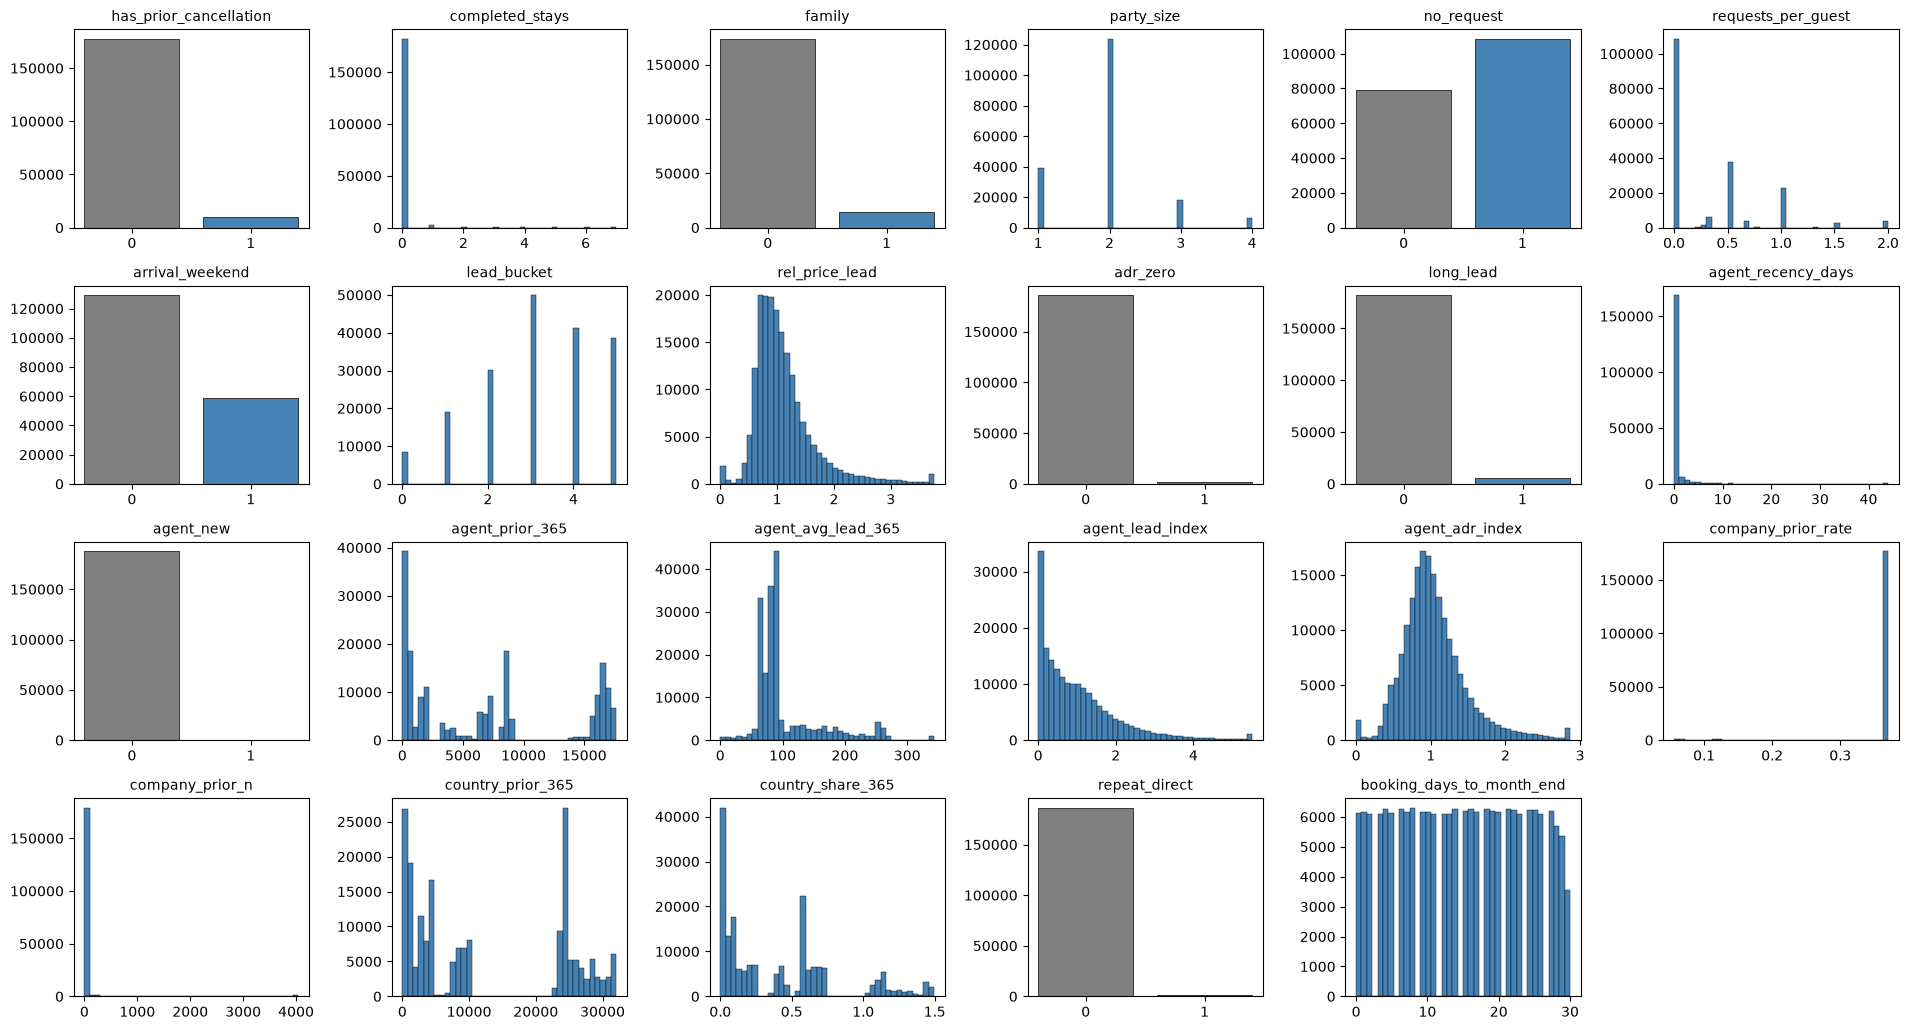

                  feature    auc   corr
          agent_prior_365 0.6423  0.255
         agent_lead_index 0.5768  0.088
           rel_price_lead 0.5684  0.082
       agent_recency_days 0.5658 -0.025
              lead_bucket 0.5588  0.109
       requests_per_guest 0.5503 -0.084
               party_size 0.5501  0.093
               no_request 0.5440  0.081
          agent_adr_index 0.5250  0.032
       company_prior_rate 0.5220  0.091
          company_prior_n 0.5214 -0.054
   has_prior_cancellation 0.5205  0.082
                   family 0.5170  0.059
        country_prior_365 0.5155  0.048
          completed_stays 0.5155 -0.037
       agent_avg_lead_365 0.5087 -0.063
        country_share_365 0.5086  0.040
                long_lead 0.5055 -0.029
          arrival_weekend 0.5048  0.009
            repeat_direct 0.5031 -0.036
                 adr_zero 0.5024 -0.023
booking_days_to_month_end 0.5015  0.002
                agent_new 0.5000  0.000


                  feature             closest_v1_feature  abs_corr
          completed_stays previous_bookings_not_canceled     1.000
               party_size                   total_guests     1.000
          agent_prior_365                  agent_prior_n     0.991
   has_prior_cancellation              prev_cancel_ratio     0.966
        country_prior_365                    is_portugal     0.964
       company_prior_rate                    has_company     0.928
           rel_price_lead                            adr     0.907
       requests_per_guest      total_of_special_requests     0.905
                   family                       children     0.896
               no_request      total_of_special_requests     0.855
        country_share_365                    is_portugal     0.850
              lead_bucket                      lead_time     0.830
         agent_lead_index                      lead_time     0.748
          agent_adr_index                            adr     0

as of audit, agent_prior_365 mismatches on 400 sampled bookings: 0


In [15]:
audit_frame = context.add_context(landmark(window_rows(cohorts["train_pool"], 3), 1, 3), weather, holidays)
audit_levels = features.fit_levels(audit_frame)
audit_x = features.transform(audit_frame, audit_levels)
audit_y = audit_frame["is_canceled"].values
new_cols = features.numeric_columns_v2
print("training pool of the last 3 years, rows " + str(len(audit_x)))
plot_new_features(audit_x, new_cols)
print(numeric_power(audit_x, audit_y, new_cols).to_string(index=False))
print(redundancy(audit_x, new_cols, features.numeric_columns_v1).to_string(index=False))
print("persona cancel rates " + json.dumps(audit_frame.assign(persona=audit_x["persona"].astype(str)).groupby("persona")["is_canceled"].mean().round(3).to_dict()))
print("as of audit, agent_prior_365 mismatches on 400 sampled bookings: " + str(as_of_audit(raw_agents)))
del audit_frame, audit_x, raw_agents

#### Leakage audit of the stream
* every synthetic booking descends from a real atom, reused several times across years; the atom's outcome in the training cohorts is used as a predictor of the validation and test outcomes
* share of validation atoms present in training, and share of copies identical to the first copy in rate, nights and requests

In [16]:
# auc of the atom's training outcome as a predictor of the outcomes of the same atom in another set
def atom_memorisation(train, other):
    atom_rate = train.groupby("source_booking_id")["is_canceled"].mean()
    seen = other["source_booking_id"].isin(atom_rate.index)
    pred = other["source_booking_id"].map(atom_rate).fillna(train["is_canceled"].mean())
    return round(float(seen.mean()), 4), round(float(roc_auc_score(other["is_canceled"], pred)), 4)

In [17]:
for name in ["valid", "on_books", "near"]:
    seen, auc = atom_memorisation(cohorts["train_pool"], cohorts[name])
    print(name + ": atoms seen in training " + str(seen) + ", auc of the atom's training outcome as predictor " + str(auc))
copies = cohorts["train_pool"].sort_values("booking_date").drop_duplicates("source_booking_id")[["source_booking_id", "adr", "nights", "total_of_special_requests"]].set_index("source_booking_id")
sample = cohorts["train_pool"].sample(min(20000, len(cohorts["train_pool"])), random_state=7)
for col in ["adr", "nights", "total_of_special_requests"]:
    print("copies identical to the first copy in " + col + ": " + str(round(float((sample[col].values == copies.loc[sample["source_booking_id"], col].values).mean()), 3)))

valid: atoms seen in training 0.9941, auc of the atom's training outcome as predictor 0.8234
on_books: atoms seen in training 0.9822, auc of the atom's training outcome as predictor 0.8197


near: atoms seen in training 0.9768, auc of the atom's training outcome as predictor 0.7975


copies identical to the first copy in adr: 0.197
copies identical to the first copy in nights: 0.805
copies identical to the first copy in total_of_special_requests: 0.873


#### Evaluation helpers

In [18]:
# expected calibration error with ten equal width bins
def ece(p, y, bins=10):
    edges = np.linspace(0, 1, bins + 1)
    total = 0.0
    for lo, hi in zip(edges[:-1], edges[1:]):
        mask = (p >= lo) & (p < hi)
        if mask.sum() == 0:
            continue
        total = total + mask.mean() * abs(p[mask].mean() - y[mask].mean())
    return float(total)

In [19]:
# discrimination and probability quality of predictions
def evaluate(p, y):
    p = np.clip(p, 1e-6, 1 - 1e-6)
    return {"rows": int(len(y)), "roc_auc": round(float(roc_auc_score(y, p)), 4), "pr_auc": round(float(average_precision_score(y, p)), 4), "brier": round(float(brier_score_loss(y, p)), 4), "log_loss": round(float(log_loss(y, p)), 4), "ece": round(ece(p, y), 4), "share_above_0.99": round(float((p > 0.99).mean()), 4)}

In [20]:
# calibrator on validation predictions, isotonic with clipped output or platt scaling on the log odds
def fit_calibrator(p_valid, y_valid, method):
    if method == "isotonic":
        iso = IsotonicRegression(y_min=clip_low, y_max=clip_high, out_of_bounds="clip")
        iso.fit(p_valid, y_valid)
        return lambda p: np.clip(iso.predict(p), clip_low, clip_high)
    logit = np.log(np.clip(p_valid, 1e-6, 1 - 1e-6) / (1 - np.clip(p_valid, 1e-6, 1 - 1e-6))).reshape(-1, 1)
    platt = LogisticRegression(C=1e6, max_iter=1000)
    platt.fit(logit, y_valid)
    return lambda p: np.clip(platt.predict_proba(np.log(np.clip(p, 1e-6, 1 - 1e-6) / (1 - np.clip(p, 1e-6, 1 - 1e-6))).reshape(-1, 1))[:, 1], clip_low, clip_high)

In [21]:
# lightgbm with early stopping on the validation slice, loss and auc recorded per iteration on both sets
def fit_lgbm(params, x_train, y_train, x_valid, y_valid, rounds=4000, patience=150, weight=None):
    d_train = lgb.Dataset(x_train, label=y_train, weight=weight)
    d_valid = lgb.Dataset(x_valid, label=y_valid, reference=d_train)
    history = {}
    callbacks = [lgb.early_stopping(patience, first_metric_only=True, verbose=False), lgb.record_evaluation(history)]
    model = lgb.train(params, d_train, num_boost_round=rounds, valid_sets=[d_train, d_valid], valid_names=["train", "validation"], callbacks=callbacks)
    curve = {"iteration": list(range(1, len(history["train"]["binary_logloss"]) + 1)), "train_loss": [round(float(v), 5) for v in history["train"]["binary_logloss"]], "test_loss": [round(float(v), 5) for v in history["validation"]["binary_logloss"]], "train_auc": [round(float(v), 5) for v in history["train"]["auc"]], "test_auc": [round(float(v), 5) for v in history["validation"]["auc"]], "best_iteration": int(model.best_iteration)}
    return model, curve

In [22]:
# learning curves, train against validation per boosting iteration for the loss and for auc
def plot_learning_curves(curve):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].plot(curve["iteration"], curve["train_loss"], color="blue", label="train")
    axes[0].plot(curve["iteration"], curve["test_loss"], color="red", label="validation")
    axes[0].axvline(curve["best_iteration"], color="gray", linestyle="--", label="best iteration")
    axes[0].set_xlabel("iteration")
    axes[0].set_ylabel("log loss")
    axes[0].legend()
    axes[1].plot(curve["iteration"], curve["train_auc"], color="blue", label="train")
    axes[1].plot(curve["iteration"], curve["test_auc"], color="red", label="validation")
    axes[1].axvline(curve["best_iteration"], color="gray", linestyle="--", label="best iteration")
    axes[1].set_xlabel("iteration")
    axes[1].set_ylabel("roc auc")
    axes[1].legend()
    fig.suptitle("Learning curves")
    plt.tight_layout()
    plt.show()

In [23]:
# percentile caps learned on the training matrix for the numeric columns
def fit_caps(x, cols, low, high):
    caps = {}
    for col in cols:
        v = pd.to_numeric(x[col], errors="coerce")
        if v.nunique() > 10:
            caps[col] = (float(v.quantile(low)), float(v.quantile(high)))
    return caps

In [24]:
# apply learned caps, either clipping to the bounds or replacing values outside them by the training median
def apply_caps(x, caps, medians, mode):
    out = x.copy()
    for col, (lo, hi) in caps.items():
        if mode == "clip":
            out[col] = out[col].clip(lo, hi)
        else:
            outside = (out[col] < lo) | (out[col] > hi)
            out[col] = out[col].where(~outside, medians[col])
    return out

In [25]:
# fitted scaler for the numeric columns, one of standard, robust or quantile, none returns the identity
def fit_scaler(x, cols, kind):
    if kind == "none":
        return None
    scaler = {"standard": StandardScaler(), "robust": RobustScaler(), "quantile": QuantileTransformer(n_quantiles=200, output_distribution="normal", random_state=7)}[kind]
    scaler.fit(x[cols].astype(float))
    return scaler

In [26]:
# apply a fitted scaler to the numeric columns, categoricals untouched
def apply_scaler(x, cols, scaler):
    if scaler is None:
        return x
    out = x.copy()
    out[cols] = scaler.transform(out[cols].astype(float))
    return out

In [27]:
# prepare the matrices of one setup: window, feature list, landmark samples, caps and scaling, everything learned on the training rows
def prepare(years, cols, k, cap=None, cap_mode="clip", scaling="none", seed=7):
    train = context.add_context(landmark(window_rows(cohorts["train_pool"], years), k, seed), weather, holidays)
    valid = context.add_context(landmark(cohorts["valid"], k, seed + 100), weather, holidays)
    levels = features.fit_levels(train)
    cat_cols = [c for c in cols if c in features.categorical_columns]
    num_cols = [c for c in cols if c not in cat_cols]
    x_train = matrix(train, levels, cols)
    x_valid = matrix(valid, levels, cols)
    tests = {name: matrix(frame, levels, cols) for name, frame in test_sets.items()}
    caps = fit_caps(x_train, num_cols, cap[0], cap[1]) if cap is not None else {}
    medians = {c: float(x_train[c].median()) for c in caps}
    scaler = fit_scaler(apply_caps(x_train, caps, medians, cap_mode), num_cols, scaling)
    finish = lambda x: apply_scaler(apply_caps(x, caps, medians, cap_mode), num_cols, scaler)
    return {"x_train": finish(x_train), "y_train": train["is_canceled"].values, "x_valid": finish(x_valid), "y_valid": valid["is_canceled"].values, "tests": {name: finish(x) for name, x in tests.items()}, "levels": levels, "caps": caps, "scaler": scaler, "num_cols": num_cols, "cat_cols": cat_cols, "rows": len(train)}

In [28]:
# run one lightgbm setup end to end and return the result row with validation and test metrics, the calibrated predictions and the curve
def run_setup(name, data, params, calibration="isotonic", weight=None, rounds=4000, patience=150):
    t0 = time.time()
    model, curve = fit_lgbm(params, data["x_train"], data["y_train"], data["x_valid"], data["y_valid"], rounds, patience, weight)
    raw_valid = model.predict(data["x_valid"], num_iteration=model.best_iteration)
    cal = fit_calibrator(raw_valid, data["y_valid"], calibration)
    row = {"name": name, "rows": data["rows"], "features": data["x_train"].shape[1], "best_iteration": curve["best_iteration"], "seconds": round(time.time() - t0), "train_loss": curve["train_loss"][curve["best_iteration"] - 1], "valid_loss": curve["test_loss"][curve["best_iteration"] - 1], "gap": round(curve["test_loss"][curve["best_iteration"] - 1] - curve["train_loss"][curve["best_iteration"] - 1], 4), "valid_auc": curve["test_auc"][curve["best_iteration"] - 1]}
    preds = {}
    for label, x in data["tests"].items():
        p = cal(model.predict(x, num_iteration=model.best_iteration))
        preds[label] = p
        m = evaluate(p, test_sets[label]["is_canceled"].values)
        for key in ["roc_auc", "brier", "ece", "share_above_0.99"]:
            row[label + "_" + key] = m[key]
    return row, model, curve, preds, cal

In [29]:
# results table with the columns that matter, sorted by the validation auc
def results_table(rows):
    cols = ["name", "rows", "features", "best_iteration", "seconds", "train_loss", "valid_loss", "gap", "valid_auc", "on_books_roc_auc", "on_books_brier", "on_books_ece", "near_roc_auc", "near_brier", "future_roc_auc", "future_brier", "on_books_share_above_0.99"]
    frame = pd.DataFrame(rows)
    return frame[[c for c in cols if c in frame.columns]]

In [30]:
# the reliability rule: among the rows whose train against validation log loss gap is within the limit, the lowest validation log loss; the smallest gap when no row qualifies
def choose_reliable(rows, limit=None):
    limit = gap_limit if limit is None else limit
    table = pd.DataFrame(rows)
    within = table[table["gap"] <= limit]
    if len(within) == 0:
        return table.sort_values("gap").iloc[0]
    return within.sort_values("valid_loss").iloc[0]

In [31]:
# results of finished stages, kept on disk so a re run resumes after an interruption
CACHE_PATH = os.path.join(MODELS_DIR, "experiments_cancellation_synth_cache.json")
def cache_load():
    if not os.path.exists(CACHE_PATH):
        return {}
    with open(CACHE_PATH) as f:
        return json.load(f)

In [32]:
# store the payload of one stage in the cache file
def cache_save(stage, payload):
    cache = cache_load()
    cache[stage] = payload
    with open(CACHE_PATH, "w") as f:
        json.dump(cache, f, default=str)

In [33]:
cache = cache_load()
print("stages already done: " + ", ".join(cache.keys()) if cache else "no cached stages")

no cached stages


#### Baseline and feature sets
* the production recipe on the stream: all history, one landmark sample to fit the memory of this server, first feature set, then the second feature set

{"name": "v1 recipe, first feature set, all history, one landmark sample", "rows": 630664, "features": 51, "best_iteration": 796, "seconds": 181, "train_loss": 0.24928, "valid_loss": 0.29165, "gap": 0.0424, "valid_auc": 0.93737, "on_books_roc_auc": 0.9121, "on_books_brier": 0.0897, "on_books_ece": 0.0185, "on_books_share_above_0.99": 0.0, "near_roc_auc": 0.8684, "near_brier": 0.2841, "near_ece": 0.3236, "near_share_above_0.99": 0.0, "future_roc_auc": 0.8974, "future_brier": 0.1809, "future_ece": 0.1828, "future_share_above_0.99": 0.0}


{"name": "v1 recipe, second feature set, all history, one landmark sample", "rows": 630664, "features": 75, "best_iteration": 1162, "seconds": 259, "train_loss": 0.23122, "valid_loss": 0.29216, "gap": 0.0609, "valid_auc": 0.93711, "on_books_roc_auc": 0.9113, "on_books_brier": 0.0904, "on_books_ece": 0.0133, "on_books_share_above_0.99": 0.0, "near_roc_auc": 0.8683, "near_brier": 0.2797, "near_ece": 0.3182, "near_share_above_0.99": 0.0, "future_roc_auc": 0.8951, "future_brier": 0.1785, "future_ece": 0.1765, "future_share_above_0.99": 0.0}


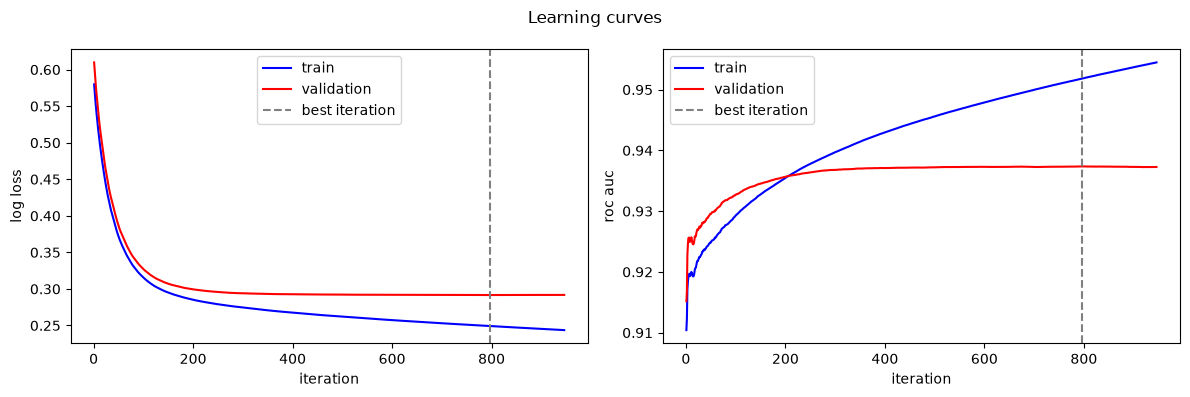

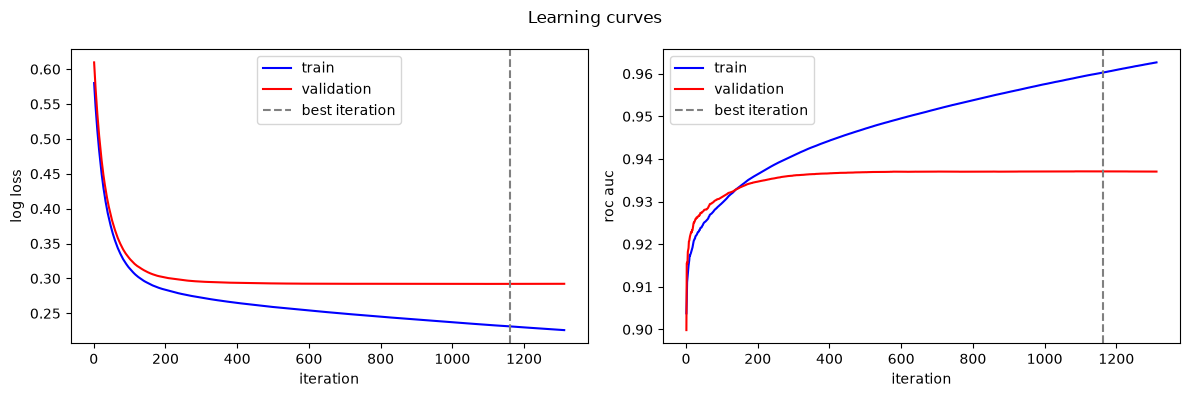

In [34]:
results = []
curves = {}
v1_cols = features.categorical_columns[:-1] + features.numeric_columns_v1
v2_cols = features.feature_names()
if "baseline" in cache:
    results = cache["baseline"]["results"]
    curves = cache["baseline"]["curves"]
    for row in results:
        print(json.dumps(row))
else:
    data_v1 = prepare(None, v1_cols, 1)
    row, model, curve, preds, cal = run_setup("v1 recipe, first feature set, all history, one landmark sample", data_v1, v1_params)
    results.append(row)
    curves[row["name"]] = curve
    print(json.dumps(row))
    del data_v1
    data_v2 = prepare(None, v2_cols, 1)
    row, model, curve, preds, cal = run_setup("v1 recipe, second feature set, all history, one landmark sample", data_v2, v1_params)
    results.append(row)
    curves[row["name"]] = curve
    print(json.dumps(row))
    del data_v2
    cache_save("baseline", {"results": results, "curves": curves})
for name in curves:
    plot_learning_curves(curves[name])

#### Training window
* the second feature set with the base parameters, one landmark sample, arrival cohorts of the last years only

In [35]:
if "window" in cache:
    results = results + cache["window"]["results"]
else:
    stage_rows = []
    for label, years in windows.items():
        data = prepare(years, v2_cols, 1)
        row, model, curve, preds, cal = run_setup("window " + label, data, base_params)
        stage_rows.append(row)
        print(json.dumps(row))
        del data
    results = results + stage_rows
    cache_save("window", {"results": stage_rows})
window_table = results_table([r for r in results if r["name"].startswith("window")])
print(window_table.to_string(index=False))
best_window = window_table.sort_values("valid_auc", ascending=False).iloc[0]["name"].replace("window ", "")
print("window chosen on validation auc: " + best_window)

{"name": "window all", "rows": 630664, "features": 75, "best_iteration": 1432, "seconds": 243, "train_loss": 0.26909, "valid_loss": 0.29241, "gap": 0.0233, "valid_auc": 0.93696, "on_books_roc_auc": 0.9112, "on_books_brier": 0.0904, "on_books_ece": 0.0147, "on_books_share_above_0.99": 0.0, "near_roc_auc": 0.8702, "near_brier": 0.2812, "near_ece": 0.323, "near_share_above_0.99": 0.0, "future_roc_auc": 0.8962, "future_brier": 0.1791, "future_ece": 0.1775, "future_share_above_0.99": 0.0}


{"name": "window 3 years", "rows": 187729, "features": 75, "best_iteration": 795, "seconds": 45, "train_loss": 0.25591, "valid_loss": 0.29751, "gap": 0.0416, "valid_auc": 0.93504, "on_books_roc_auc": 0.9011, "on_books_brier": 0.0941, "on_books_ece": 0.0177, "on_books_share_above_0.99": 0.0, "near_roc_auc": 0.8681, "near_brier": 0.2889, "near_ece": 0.3371, "near_share_above_0.99": 0.0, "future_roc_auc": 0.8933, "future_brier": 0.1897, "future_ece": 0.2004, "future_share_above_0.99": 0.0}
          name   rows  features  best_iteration  seconds  train_loss  valid_loss    gap  valid_auc  on_books_roc_auc  on_books_brier  on_books_ece  near_roc_auc  near_brier  future_roc_auc  future_brier  on_books_share_above_0.99
    window all 630664        75            1432      243     0.26909     0.29241 0.0233    0.93696            0.9112          0.0904        0.0147        0.8702      0.2812          0.8962        0.1791                        0.0
window 3 years 187729        75             795 

#### Outlier treatment
* percentile caps learned on the training rows, clipping or replacement by the training median, on the chosen window

In [36]:
cap_options = {"none": (None, "clip"), "clip 1 to 99": ((0.01, 0.99), "clip"), "clip 3 to 97": ((0.03, 0.97), "clip"), "clip 5 to 95": ((0.05, 0.95), "clip"), "median outside 1 to 99": ((0.01, 0.99), "median")}
if quick:
    cap_options = {"none": (None, "clip"), "clip 3 to 97": ((0.03, 0.97), "clip")}
if "outliers" in cache:
    results = results + cache["outliers"]["results"]
else:
    stage_rows = []
    for label, (cap, mode) in cap_options.items():
        data = prepare(windows[best_window], v2_cols, 1, cap=cap, cap_mode=mode)
        row, model, curve, preds, cal = run_setup("outliers " + label, data, base_params)
        stage_rows.append(row)
        print(json.dumps(row))
        del data
    results = results + stage_rows
    cache_save("outliers", {"results": stage_rows})
cap_table = results_table([r for r in results if r["name"].startswith("outliers")])
print(cap_table.to_string(index=False))
best_cap = cap_table.sort_values("valid_auc", ascending=False).iloc[0]["name"].replace("outliers ", "")
print("outlier treatment chosen on validation auc: " + best_cap)

{"name": "outliers none", "rows": 630664, "features": 75, "best_iteration": 1432, "seconds": 242, "train_loss": 0.26909, "valid_loss": 0.29241, "gap": 0.0233, "valid_auc": 0.93696, "on_books_roc_auc": 0.9112, "on_books_brier": 0.0904, "on_books_ece": 0.0147, "on_books_share_above_0.99": 0.0, "near_roc_auc": 0.8702, "near_brier": 0.2812, "near_ece": 0.323, "near_share_above_0.99": 0.0, "future_roc_auc": 0.8962, "future_brier": 0.1791, "future_ece": 0.1775, "future_share_above_0.99": 0.0}


{"name": "outliers clip 3 to 97", "rows": 630664, "features": 75, "best_iteration": 1611, "seconds": 292, "train_loss": 0.26726, "valid_loss": 0.29264, "gap": 0.0254, "valid_auc": 0.93687, "on_books_roc_auc": 0.9099, "on_books_brier": 0.091, "on_books_ece": 0.0143, "on_books_share_above_0.99": 0.0, "near_roc_auc": 0.8705, "near_brier": 0.2839, "near_ece": 0.3267, "near_share_above_0.99": 0.0, "future_roc_auc": 0.8945, "future_brier": 0.1813, "future_ece": 0.1824, "future_share_above_0.99": 0.0}
                 name   rows  features  best_iteration  seconds  train_loss  valid_loss    gap  valid_auc  on_books_roc_auc  on_books_brier  on_books_ece  near_roc_auc  near_brier  future_roc_auc  future_brier  on_books_share_above_0.99
        outliers none 630664        75            1432      242     0.26909     0.29241 0.0233    0.93696            0.9112          0.0904        0.0147        0.8702      0.2812          0.8962        0.1791                        0.0
outliers clip 3 to 97 6306

#### Scaling
* standard, robust and quantile scalers fit on the training rows, applied to the numeric features, for the boosted model and for a logistic regression

In [37]:
# logistic regression on scaled numeric features and one hot categoricals, probability on the validation and test matrices
def fit_logistic(data, c=0.5):
    pre = ColumnTransformer([("cat", OneHotEncoder(handle_unknown="ignore", min_frequency=50), data["cat_cols"]), ("num", "passthrough", data["num_cols"])])
    model = Pipeline([("pre", pre), ("clf", LogisticRegression(max_iter=2000, C=c))])
    xt = data["x_train"].copy()
    for c_ in data["cat_cols"]:
        xt[c_] = xt[c_].astype(str)
    model.fit(xt, data["y_train"])
    def predict(x):
        xx = x.copy()
        for c_ in data["cat_cols"]:
            xx[c_] = xx[c_].astype(str)
        return model.predict_proba(xx)[:, 1]
    return model, predict

In [38]:
# run a non boosted model end to end, calibrated on validation, with validation and test metrics
def run_other(name, data, fit, calibration="isotonic"):
    t0 = time.time()
    model, predict = fit(data)
    raw_valid = predict(data["x_valid"])
    cal = fit_calibrator(raw_valid, data["y_valid"], calibration)
    row = {"name": name, "rows": data["rows"], "features": data["x_train"].shape[1], "best_iteration": 0, "seconds": round(time.time() - t0), "train_loss": round(float(log_loss(data["y_train"], np.clip(predict(data["x_train"]), 1e-6, 1 - 1e-6))), 5), "valid_loss": round(float(log_loss(data["y_valid"], np.clip(raw_valid, 1e-6, 1 - 1e-6))), 5), "valid_auc": round(float(roc_auc_score(data["y_valid"], raw_valid)), 5)}
    row["gap"] = round(row["valid_loss"] - row["train_loss"], 4)
    preds = {}
    for label, x in data["tests"].items():
        p = cal(predict(x))
        preds[label] = p
        m = evaluate(p, test_sets[label]["is_canceled"].values)
        for key in ["roc_auc", "brier", "ece", "share_above_0.99"]:
            row[label + "_" + key] = m[key]
    return row, model, preds, cal, predict

In [39]:
cap_choice = cap_options[best_cap]
if "scaling" in cache:
    results = results + cache["scaling"]["results"]
else:
    stage_rows = []
    for kind in (["none", "standard"] if quick else ["none", "standard", "robust", "quantile"]):
        data = prepare(windows[best_window], v2_cols, 1, cap=cap_choice[0], cap_mode=cap_choice[1], scaling=kind)
        if kind == "none" or not quick:
            row, model, curve, preds, cal = run_setup("scaling " + kind + ", lightgbm", data, base_params)
            stage_rows.append(row)
            print(json.dumps(row))
        row, model, preds, cal, predict = run_other("scaling " + kind + ", logistic", data, fit_logistic)
        stage_rows.append(row)
        print(json.dumps(row))
        del data
    results = results + stage_rows
    cache_save("scaling", {"results": stage_rows})
print(results_table([r for r in results if r["name"].startswith("scaling")]).to_string(index=False))

{"name": "scaling none, lightgbm", "rows": 630664, "features": 75, "best_iteration": 1432, "seconds": 252, "train_loss": 0.26909, "valid_loss": 0.29241, "gap": 0.0233, "valid_auc": 0.93696, "on_books_roc_auc": 0.9112, "on_books_brier": 0.0904, "on_books_ece": 0.0147, "on_books_share_above_0.99": 0.0, "near_roc_auc": 0.8702, "near_brier": 0.2812, "near_ece": 0.323, "near_share_above_0.99": 0.0, "future_roc_auc": 0.8962, "future_brier": 0.1791, "future_ece": 0.1775, "future_share_above_0.99": 0.0}


{"name": "scaling none, logistic", "rows": 630664, "features": 75, "best_iteration": 0, "seconds": 359, "train_loss": 0.518, "valid_loss": 0.50143, "valid_auc": 0.79606, "gap": -0.0166, "on_books_roc_auc": 0.6914, "on_books_brier": 0.1456, "on_books_ece": 0.069, "on_books_share_above_0.99": 0.0, "near_roc_auc": 0.6552, "near_brier": 0.249, "near_ece": 0.1669, "near_share_above_0.99": 0.0, "future_roc_auc": 0.7806, "future_brier": 0.1865, "future_ece": 0.083, "future_share_above_0.99": 0.0}


{"name": "scaling standard, logistic", "rows": 630664, "features": 75, "best_iteration": 0, "seconds": 65, "train_loss": 0.35676, "valid_loss": 0.36057, "valid_auc": 0.9024, "gap": 0.0038, "on_books_roc_auc": 0.8875, "on_books_brier": 0.1025, "on_books_ece": 0.0161, "on_books_share_above_0.99": 0.0, "near_roc_auc": 0.8495, "near_brier": 0.1986, "near_ece": 0.2042, "near_share_above_0.99": 0.0, "future_roc_auc": 0.8647, "future_brier": 0.1528, "future_ece": 0.0772, "future_share_above_0.99": 0.0}
                      name   rows  features  best_iteration  seconds  train_loss  valid_loss     gap  valid_auc  on_books_roc_auc  on_books_brier  on_books_ece  near_roc_auc  near_brier  future_roc_auc  future_brier  on_books_share_above_0.99
    scaling none, lightgbm 630664        75            1432      252     0.26909     0.29241  0.0233    0.93696            0.9112          0.0904        0.0147        0.8702      0.2812          0.8962        0.1791                        0.0
    scaling n

#### Feature selection
* hybrid stepwise on a fast boosted model: forward additions in order of gain when the validation log loss falls, backward removal of features whose removal does not raise it
* logistic stepwise by p value on the scaled features as in the statistics reference, for comparison
* the full set, the stepwise selection, the features above 0.1 percent of the gain, and the same without the agent and company identities, compared at the same parameters and chosen by the reliability rule

In [40]:
# validation auc and log loss of a fast boosted model on a feature list
def fast_scores(data, cols):
    model, curve = fit_lgbm(fast_params, data["x_train"][cols], data["y_train"], data["x_valid"][cols], data["y_valid"], rounds=400, patience=30)
    b = curve["best_iteration"] - 1
    return curve["test_auc"][b], curve["test_loss"][b]


# validation auc of a fast boosted model on a feature list
def fast_auc(data, cols):
    return fast_scores(data, cols)[0]

In [41]:
# hybrid stepwise selection on validation log loss: forward additions in importance order when the loss falls by more than the tolerance, backward removal of features whose removal does not raise the loss by more than the tolerance, at most three passes
def hybrid_stepwise_gbdt(data, order, tolerance=0.0003, patience_features=25, max_passes=3):
    included = []
    remaining = list(order)
    best_loss = 10.0
    best_auc = 0.0
    step = 0
    for sweep in range(max_passes):
        changed = False
        misses = 0
        for feat in list(remaining):
            auc, loss = fast_scores(data, included + [feat])
            if loss < best_loss - tolerance:
                included.append(feat)
                remaining.remove(feat)
                best_loss, best_auc = loss, auc
                step = step + 1
                misses = 0
                changed = True
                print("step " + str(step) + ": added " + feat + ", validation log loss " + str(round(best_loss, 5)) + ", auc " + str(round(best_auc, 5)))
            else:
                misses = misses + 1
            if misses >= patience_features:
                break
        for feat in list(included):
            if len(included) <= 5:
                break
            auc, loss = fast_scores(data, [c for c in included if c != feat])
            if loss <= best_loss + tolerance:
                included.remove(feat)
                remaining.append(feat)
                best_loss, best_auc = min(best_loss, loss), auc
                step = step + 1
                changed = True
                print("step " + str(step) + ": removed " + feat + ", validation log loss " + str(round(best_loss, 5)) + ", auc " + str(round(best_auc, 5)))
        if not changed:
            break
    return included, best_auc

In [42]:
# logit fit that returns none when the design matrix is singular or the fit does not converge
def safe_logit(x, y, cols):
    try:
        model = sm.Logit(y, sm.add_constant(x[cols])).fit(disp=0, maxiter=100)
    except (np.linalg.LinAlgError, ValueError):
        return None
    if not np.all(np.isfinite(model.pvalues.values)):
        return None
    return model

In [43]:
# logistic stepwise by p value on the scaled numeric features, forward additions in order of absolute correlation with the target, backward removal of insignificant ones
def hybrid_stepwise_logit(x, y, order, significance=0.01, max_features=25):
    included = []
    remaining = list(order)
    improved = True
    while improved and len(included) < max_features:
        improved = False
        for feat in list(remaining):
            model = safe_logit(x, y, included + [feat])
            if model is not None and model.pvalues[feat] <= significance:
                included.append(feat)
                remaining.remove(feat)
                improved = True
            if len(included) >= max_features:
                break
        model = safe_logit(x, y, included) if included else None
        if model is not None:
            for feat in list(included):
                if model.pvalues[feat] > significance:
                    included.remove(feat)
                    remaining.append(feat)
                    improved = True
    return included

In [44]:
if "stepwise" in cache:
    selected = cache["stepwise"]["selected"]
    selected_auc = cache["stepwise"]["selected_auc"]
    gain = pd.Series(cache["stepwise"]["gain"])
    print("gain share of the full model, top 25")
    print((gain / gain.sum()).head(25).round(4).to_string())
else:
    sel_data = prepare(windows[best_window], v2_cols, 1, cap=cap_choice[0], cap_mode=cap_choice[1])
    full_model, full_curve = fit_lgbm(base_params, sel_data["x_train"], sel_data["y_train"], sel_data["x_valid"], sel_data["y_valid"])
    gain = pd.Series(full_model.feature_importance("gain"), index=full_model.feature_name()).sort_values(ascending=False)
    print("gain share of the full model, top 25")
    print((gain / gain.sum()).head(25).round(4).to_string())
    selected, selected_auc = hybrid_stepwise_gbdt(sel_data, gain.index.tolist())
    del sel_data
    cache_save("stepwise", {"selected": selected, "selected_auc": selected_auc, "gain": {k: float(v) for k, v in gain.items()}})
print("selected " + str(len(selected)) + " of " + str(len(v2_cols)) + " features, validation auc of the fast model " + str(round(selected_auc, 5)))
print(", ".join(selected))

gain share of the full model, top 25
survived_share                 0.1930
agent                          0.1056
days_to_arrival                0.0841
lead_time                      0.0739
country                        0.0704
days_since_booking             0.0651
required_car_parking_spaces    0.0414
deposit_type                   0.0362
agent_prior_rate               0.0296
is_portugal                    0.0292
prev_cancel_ratio              0.0292
country_share_365              0.0236
customer_type                  0.0226
total_of_special_requests      0.0217
agent_lead_index               0.0144
market_segment                 0.0141
no_request                     0.0132
requests_per_guest             0.0114
arr_weather_known              0.0099
country_prior_rate             0.0085
agent_avg_lead_365             0.0071
agent_prior_n                  0.0065
previous_cancellations         0.0060
agent_prior_365                0.0058
nights                         0.0055


step 1: added survived_share, validation log loss 0.5184, auc 0.7738


step 2: added agent, validation log loss 0.44544, auc 0.84357


step 3: added days_to_arrival, validation log loss 0.41584, auc 0.86002


step 4: added lead_time, validation log loss 0.41231, auc 0.86241


...

step 16: added previous_bookings_not_canceled, validation log loss 0.29651, auc 0.93491


step 17: added arr_temp_max, validation log loss 0.29617, auc 0.93511


step 18: added adr, validation log loss 0.29495, auc 0.93572


step 19: added meal, validation log loss 0.29386, auc 0.93625


selected 19 of 75 features, validation auc of the fast model 0.93625
survived_share, agent, days_to_arrival, lead_time, country, required_car_parking_spaces, deposit_type, prev_cancel_ratio, customer_type, total_of_special_requests, agent_lead_index, market_segment, country_prior_rate, agent_prior_365, arrival_week, previous_bookings_not_canceled, arr_temp_max, adr, meal


In [45]:
if quick:
    logit_selected = []
elif "stepwise_logit" in cache:
    logit_selected = cache["stepwise_logit"]["selected"]
else:
    scaled = prepare(windows[best_window], v2_cols, 1, cap=cap_choice[0], cap_mode=cap_choice[1], scaling="standard")
    logit_sample = scaled["x_train"][scaled["num_cols"]].sample(min(60000, len(scaled["x_train"])), random_state=7)
    logit_y = scaled["y_train"][logit_sample.index.values]
    logit_sample = logit_sample.loc[:, logit_sample.std() > 0]
    corr_order = logit_sample.corrwith(pd.Series(logit_y, index=logit_sample.index)).abs().sort_values(ascending=False).index.tolist()
    logit_selected = hybrid_stepwise_logit(logit_sample.reset_index(drop=True), logit_y, corr_order)
    del scaled
    cache_save("stepwise_logit", {"selected": logit_selected})
print("logistic stepwise kept " + str(len(logit_selected)) + " numeric features: " + ", ".join(logit_selected))
print("in both selections: " + ", ".join(sorted(set(logit_selected) & set(selected))))

logistic stepwise kept 0 numeric features: 
in both selections: 


In [46]:
pruned = [c for c in v2_cols if c in gain.index and gain[c] / gain.sum() >= 0.001]
candidates = {"features full second set": v2_cols, "features stepwise selection": selected, "features gain pruned": pruned, "features gain pruned without agent and company ids": [c for c in pruned if c not in ("agent", "company")]}
if "features" in cache:
    results = results + cache["features"]["results"]
    curves.update(cache["features"]["curves"])
else:
    stage_rows = []
    stage_curves = {}
    for label, cols in candidates.items():
        data = prepare(windows[best_window], cols, 1, cap=cap_choice[0], cap_mode=cap_choice[1])
        row, model, curve, preds, cal = run_setup(label, data, base_params)
        stage_rows.append(row)
        stage_curves[row["name"]] = curve
        print(json.dumps(row))
        del data
    results = results + stage_rows
    curves.update(stage_curves)
    cache_save("features", {"results": stage_rows, "curves": stage_curves})
feature_table = results_table([r for r in results if r["name"].startswith("features")])
print(feature_table.to_string(index=False))
chosen = choose_reliable([r for r in results if r["name"].startswith("features")])
final_cols = candidates[chosen["name"]]
print("feature set chosen by the reliability rule: " + chosen["name"])
print("feature set chosen: " + str(len(final_cols)) + " features")

{"name": "features full second set", "rows": 630664, "features": 75, "best_iteration": 1432, "seconds": 242, "train_loss": 0.26909, "valid_loss": 0.29241, "gap": 0.0233, "valid_auc": 0.93696, "on_books_roc_auc": 0.9112, "on_books_brier": 0.0904, "on_books_ece": 0.0147, "on_books_share_above_0.99": 0.0, "near_roc_auc": 0.8702, "near_brier": 0.2812, "near_ece": 0.323, "near_share_above_0.99": 0.0, "future_roc_auc": 0.8962, "future_brier": 0.1791, "future_ece": 0.1775, "future_share_above_0.99": 0.0}


{"name": "features stepwise selection", "rows": 630664, "features": 19, "best_iteration": 1669, "seconds": 206, "train_loss": 0.27391, "valid_loss": 0.29296, "gap": 0.0191, "valid_auc": 0.93671, "on_books_roc_auc": 0.9127, "on_books_brier": 0.0901, "on_books_ece": 0.0123, "on_books_share_above_0.99": 0.0, "near_roc_auc": 0.8676, "near_brier": 0.2839, "near_ece": 0.3252, "near_share_above_0.99": 0.0, "future_roc_auc": 0.8974, "future_brier": 0.1831, "future_ece": 0.1855, "future_share_above_0.99": 0.0}


{"name": "features gain pruned", "rows": 630664, "features": 49, "best_iteration": 1313, "seconds": 205, "train_loss": 0.2708, "valid_loss": 0.29321, "gap": 0.0224, "valid_auc": 0.93665, "on_books_roc_auc": 0.9108, "on_books_brier": 0.0908, "on_books_ece": 0.0127, "on_books_share_above_0.99": 0.0, "near_roc_auc": 0.8714, "near_brier": 0.2835, "near_ece": 0.3262, "near_share_above_0.99": 0.0, "future_roc_auc": 0.8955, "future_brier": 0.1813, "future_ece": 0.1834, "future_share_above_0.99": 0.0}


{"name": "features gain pruned without agent and company ids", "rows": 630664, "features": 47, "best_iteration": 1197, "seconds": 203, "train_loss": 0.27432, "valid_loss": 0.2954, "gap": 0.0211, "valid_auc": 0.93569, "on_books_roc_auc": 0.91, "on_books_brier": 0.0914, "on_books_ece": 0.0147, "on_books_share_above_0.99": 0.0, "near_roc_auc": 0.8687, "near_brier": 0.2877, "near_ece": 0.3298, "near_share_above_0.99": 0.0, "future_roc_auc": 0.8949, "future_brier": 0.1814, "future_ece": 0.183, "future_share_above_0.99": 0.0}
                                              name   rows  features  best_iteration  seconds  train_loss  valid_loss    gap  valid_auc  on_books_roc_auc  on_books_brier  on_books_ece  near_roc_auc  near_brier  future_roc_auc  future_brier  on_books_share_above_0.99
                          features full second set 630664        75            1432      242     0.26909     0.29241 0.0233    0.93696            0.9112          0.0904        0.0147        0.8702      0.2812

#### Hyperparameters
* random search over a regularised grid on the chosen window and features, the base parameters as the reference row
* the reliability rule picks the configuration: lowest validation log loss among those whose train against validation gap stays within the limit
* then a loop that raises regularisation while the gap is above the limit and widens capacity otherwise

In [47]:
# one random configuration from the regularised grid: shallow trees, large leaves, strong shrinkage and smoothing of the categorical splits
def random_config(gen):
    return {"learning_rate": float(gen.choice([0.03, 0.05, 0.08])), "num_leaves": int(gen.choice([7, 15, 31, 63])), "min_data_in_leaf": int(gen.choice([200, 500, 1000, 2000])), "feature_fraction": float(gen.choice([0.4, 0.5, 0.6, 0.7])), "bagging_fraction": float(gen.choice([0.6, 0.7, 0.8])), "lambda_l2": float(gen.choice([10.0, 30.0, 100.0, 300.0])), "lambda_l1": float(gen.choice([0.0, 1.0, 5.0])), "max_depth": int(gen.choice([4, 6, 8, -1])), "min_gain_to_split": float(gen.choice([0.05, 0.1, 0.5])), "extra_trees": bool(gen.choice([False, True])), "path_smooth": float(gen.choice([1.0, 10.0, 50.0])), "cat_smooth": float(gen.choice([50.0, 100.0, 300.0])), "cat_l2": float(gen.choice([10.0, 50.0])), "min_data_per_group": int(gen.choice([100, 500])), "max_bin": int(gen.choice([63, 127]))}

In [48]:
# regularise a configuration one notch or widen it one notch
def adjust(config, direction):
    out = dict(config)
    if direction == "regularise":
        out["min_data_in_leaf"] = int(out["min_data_in_leaf"] * 1.5)
        out["lambda_l2"] = out["lambda_l2"] * 2
        out["feature_fraction"] = max(0.4, round(out["feature_fraction"] - 0.1, 2))
    else:
        out["num_leaves"] = int(out["num_leaves"] * 1.5)
        out["max_depth"] = -1 if out["max_depth"] == -1 else out["max_depth"] + 2
        out["min_data_in_leaf"] = max(50, int(out["min_data_in_leaf"] / 1.5))
    return out

In [49]:
search_data = prepare(windows[best_window], final_cols, 1, cap=cap_choice[0], cap_mode=cap_choice[1])
if "search" in cache:
    search_rows = cache["search"]["rows"]
else:
    gen = np.random.default_rng(3)
    search_rows = list(cache.get("search_partial", {}).get("rows", []))
    done = len([r for r in search_rows if not r["name"].startswith("search 0")])
    if not any(r["name"].startswith("search 0") for r in search_rows):
        row, model, curve, preds, cal = run_setup("search 0 base parameters", search_data, base_params, rounds=3000, patience=100)
        row["config"] = {k: base_params[k] for k in ["learning_rate", "num_leaves", "min_data_in_leaf", "feature_fraction", "bagging_fraction", "lambda_l2"]}
        search_rows.append(row)
        cache_save("search_partial", {"rows": search_rows})
        print("search 0 base parameters: valid auc " + str(row["valid_auc"]) + ", gap " + str(row["gap"]) + ", best iteration " + str(row["best_iteration"]))
    for i in range(8 if quick else 30):
        config = random_config(gen)
        if i < done:
            continue
        params = dict(base_params)
        params.update(config)
        row, model, curve, preds, cal = run_setup("search " + str(i + 1), search_data, params, rounds=3000, patience=100)
        row["config"] = config
        search_rows.append(row)
        print("search " + str(i + 1) + ": valid auc " + str(row["valid_auc"]) + ", gap " + str(row["gap"]) + ", best iteration " + str(row["best_iteration"]) + ", " + json.dumps(config))
        cache_save("search_partial", {"rows": search_rows})
    cache_save("search", {"rows": search_rows})
print(results_table(search_rows).sort_values("valid_loss").head(10).to_string(index=False))
best_search = choose_reliable(search_rows)
print("chosen by the reliability rule: " + best_search["name"] + ", validation log loss " + str(best_search["valid_loss"]) + ", gap " + str(best_search["gap"]) + ", validation auc " + str(best_search["valid_auc"]))

search 0 base parameters: valid auc 0.93694, gap 0.0205, best iteration 1181


search 1: valid auc 0.93596, gap 0.0083, best iteration 2522, {"learning_rate": 0.08, "num_leaves": 7, "min_data_in_leaf": 200, "feature_fraction": 0.4, "bagging_fraction": 0.6, "lambda_l2": 300.0, "lambda_l1": 5.0, "max_depth": 8, "min_gain_to_split": 0.05, "extra_trees": false, "path_smooth": 1.0, "cat_smooth": 100.0, "cat_l2": 50.0, "min_data_per_group": 100, "max_bin": 63}


search 2: valid auc 0.93704, gap 0.0142, best iteration 1498, {"learning_rate": 0.03, "num_leaves": 31, "min_data_in_leaf": 1000, "feature_fraction": 0.4, "bagging_fraction": 0.6, "lambda_l2": 30.0, "lambda_l1": 1.0, "max_depth": -1, "min_gain_to_split": 0.1, "extra_trees": false, "path_smooth": 10.0, "cat_smooth": 100.0, "cat_l2": 50.0, "min_data_per_group": 100, "max_bin": 127}


search 3: valid auc 0.93673, gap 0.0176, best iteration 772, {"learning_rate": 0.08, "num_leaves": 63, "min_data_in_leaf": 2000, "feature_fraction": 0.5, "bagging_fraction": 0.6, "lambda_l2": 100.0, "lambda_l1": 1.0, "max_depth": 8, "min_gain_to_split": 0.5, "extra_trees": false, "path_smooth": 50.0, "cat_smooth": 50.0, "cat_l2": 10.0, "min_data_per_group": 500, "max_bin": 127}


search 4: valid auc 0.93548, gap 0.0062, best iteration 2985, {"learning_rate": 0.03, "num_leaves": 7, "min_data_in_leaf": 500, "feature_fraction": 0.4, "bagging_fraction": 0.8, "lambda_l2": 100.0, "lambda_l1": 1.0, "max_depth": 4, "min_gain_to_split": 0.1, "extra_trees": false, "path_smooth": 50.0, "cat_smooth": 100.0, "cat_l2": 10.0, "min_data_per_group": 100, "max_bin": 127}


search 5: valid auc 0.93702, gap 0.0137, best iteration 2383, {"learning_rate": 0.05, "num_leaves": 15, "min_data_in_leaf": 500, "feature_fraction": 0.4, "bagging_fraction": 0.7, "lambda_l2": 100.0, "lambda_l1": 1.0, "max_depth": -1, "min_gain_to_split": 0.5, "extra_trees": false, "path_smooth": 10.0, "cat_smooth": 100.0, "cat_l2": 10.0, "min_data_per_group": 100, "max_bin": 63}


search 6: valid auc 0.93654, gap 0.0135, best iteration 1201, {"learning_rate": 0.08, "num_leaves": 15, "min_data_in_leaf": 1000, "feature_fraction": 0.6, "bagging_fraction": 0.6, "lambda_l2": 30.0, "lambda_l1": 5.0, "max_depth": -1, "min_gain_to_split": 0.1, "extra_trees": false, "path_smooth": 50.0, "cat_smooth": 50.0, "cat_l2": 50.0, "min_data_per_group": 500, "max_bin": 63}


search 7: valid auc 0.93671, gap 0.0158, best iteration 245, {"learning_rate": 0.08, "num_leaves": 63, "min_data_in_leaf": 500, "feature_fraction": 0.7, "bagging_fraction": 0.7, "lambda_l2": 10.0, "lambda_l1": 1.0, "max_depth": -1, "min_gain_to_split": 0.1, "extra_trees": false, "path_smooth": 50.0, "cat_smooth": 100.0, "cat_l2": 10.0, "min_data_per_group": 100, "max_bin": 63}


search 8: valid auc 0.9369, gap 0.0186, best iteration 344, {"learning_rate": 0.08, "num_leaves": 63, "min_data_in_leaf": 500, "feature_fraction": 0.6, "bagging_fraction": 0.8, "lambda_l2": 10.0, "lambda_l1": 0.0, "max_depth": 8, "min_gain_to_split": 0.1, "extra_trees": false, "path_smooth": 10.0, "cat_smooth": 50.0, "cat_l2": 50.0, "min_data_per_group": 500, "max_bin": 63}
                    name   rows  features  best_iteration  seconds  train_loss  valid_loss    gap  valid_auc  on_books_roc_auc  on_books_brier  on_books_ece  near_roc_auc  near_brier  future_roc_auc  future_brier  on_books_share_above_0.99
                search 5 630664        75            2383      402     0.27869     0.29239 0.0137    0.93702            0.9116          0.0904        0.0140        0.8694      0.2893          0.8944        0.1853                        0.0
                search 2 630664        75            1498      294     0.27823     0.29241 0.0142    0.93704            0.9121          0.0904 

In [50]:
if "adaptive" in cache:
    results = results + cache["adaptive"]["results"]
    best_config = cache["adaptive"]["best_config"]
    stage_rows = cache["adaptive"]["results"]
else:
    current = dict(best_search["config"])
    best_loss = float(best_search["valid_loss"])
    best_gap = float(best_search["gap"])
    stage_rows = []
    for step in range(6):
        direction = "regularise" if best_gap > gap_limit else "widen"
        candidate = adjust(current, direction)
        params = dict(base_params)
        params.update(candidate)
        row, model, curve, preds, cal = run_setup("adaptive " + str(step + 1) + " " + direction, search_data, params, rounds=3000, patience=100)
        row["config"] = candidate
        results.append(row)
        stage_rows.append(row)
        print("adaptive " + str(step + 1) + " " + direction + ": valid loss " + str(row["valid_loss"]) + ", gap " + str(row["gap"]) + ", valid auc " + str(row["valid_auc"]) + ", " + json.dumps(candidate))
        if direction == "widen":
            accepted = row["gap"] <= gap_limit and row["valid_loss"] < best_loss - 0.0005
        else:
            accepted = row["gap"] < best_gap and row["valid_loss"] <= best_loss + 0.002
        if not accepted:
            break
        best_loss = float(row["valid_loss"])
        best_gap = float(row["gap"])
        current = dict(candidate)
    chosen_row = choose_reliable(search_rows + stage_rows)
    best_config = dict(chosen_row["config"])
    cache_save("adaptive", {"results": stage_rows, "best_config": best_config})
best_params = dict(base_params)
best_params.update(best_config)
chosen_row = choose_reliable(search_rows + stage_rows)
print("chosen configuration by the reliability rule: " + chosen_row["name"] + ", validation log loss " + str(chosen_row["valid_loss"]) + ", gap " + str(chosen_row["gap"]) + ", validation auc " + str(chosen_row["valid_auc"]) + ": " + json.dumps(best_config))

adaptive 1 widen: valid loss 0.29207, gap 0.0166, valid auc 0.93714, {"learning_rate": 0.05, "num_leaves": 22, "min_data_in_leaf": 333, "feature_fraction": 0.4, "bagging_fraction": 0.7, "lambda_l2": 100.0, "lambda_l1": 1.0, "max_depth": -1, "min_gain_to_split": 0.5, "extra_trees": false, "path_smooth": 10.0, "cat_smooth": 100.0, "cat_l2": 10.0, "min_data_per_group": 100, "max_bin": 63}
chosen configuration by the reliability rule: adaptive 1 widen, validation log loss 0.29207, gap 0.0166, validation auc 0.93714: {"learning_rate": 0.05, "num_leaves": 22, "min_data_in_leaf": 333, "feature_fraction": 0.4, "bagging_fraction": 0.7, "lambda_l2": 100.0, "lambda_l1": 1.0, "max_depth": -1, "min_gain_to_split": 0.5, "extra_trees": false, "path_smooth": 10.0, "cat_smooth": 100.0, "cat_l2": 10.0, "min_data_per_group": 100, "max_bin": 63}


#### Feature set under the tuned parameters
* the chosen configuration refit on the stepwise selection and on the gain pruned set, the reliability rule decides which set carries on to the remaining stages

In [51]:
if "features_tuned" in cache:
    results = results + cache["features_tuned"]["results"]
else:
    stage_rows = []
    for label, cols in {"tuned features stepwise selection": selected, "tuned features gain pruned": pruned}.items():
        data = prepare(windows[best_window], cols, 1, cap=cap_choice[0], cap_mode=cap_choice[1])
        row, model, curve, preds, cal = run_setup(label, data, best_params)
        stage_rows.append(row)
        print(json.dumps(row))
        del data
    results = results + stage_rows
    cache_save("features_tuned", {"results": stage_rows})
print(results_table([r for r in results if r["name"].startswith("tuned features")]).to_string(index=False))
chosen = choose_reliable([r for r in results if r["name"].startswith("tuned features")])
final_cols = selected if "stepwise" in chosen["name"] else pruned
print("feature set carried on: " + chosen["name"] + ", " + str(len(final_cols)) + " features")
del search_data
search_data = prepare(windows[best_window], final_cols, 1, cap=cap_choice[0], cap_mode=cap_choice[1])

{"name": "tuned features stepwise selection", "rows": 630664, "features": 19, "best_iteration": 1747, "seconds": 226, "train_loss": 0.28349, "valid_loss": 0.29385, "gap": 0.0104, "valid_auc": 0.93639, "on_books_roc_auc": 0.9122, "on_books_brier": 0.0903, "on_books_ece": 0.0192, "on_books_share_above_0.99": 0.0, "near_roc_auc": 0.8674, "near_brier": 0.2891, "near_ece": 0.3325, "near_share_above_0.99": 0.0, "future_roc_auc": 0.8947, "future_brier": 0.1855, "future_ece": 0.1889, "future_share_above_0.99": 0.0}


{"name": "tuned features gain pruned", "rows": 630664, "features": 49, "best_iteration": 2179, "seconds": 346, "train_loss": 0.27498, "valid_loss": 0.29249, "gap": 0.0175, "valid_auc": 0.93693, "on_books_roc_auc": 0.9126, "on_books_brier": 0.0898, "on_books_ece": 0.0134, "on_books_share_above_0.99": 0.0, "near_roc_auc": 0.8706, "near_brier": 0.2885, "near_ece": 0.3342, "near_share_above_0.99": 0.0, "future_roc_auc": 0.8941, "future_brier": 0.1851, "future_ece": 0.1894, "future_share_above_0.99": 0.0}
                             name   rows  features  best_iteration  seconds  train_loss  valid_loss    gap  valid_auc  on_books_roc_auc  on_books_brier  on_books_ece  near_roc_auc  near_brier  future_roc_auc  future_brier  on_books_share_above_0.99
tuned features stepwise selection 630664        19            1747      226     0.28349     0.29385 0.0104    0.93639            0.9122          0.0903        0.0192        0.8674      0.2891          0.8947        0.1855                        

#### Class weights
* positive class weight and balanced sample weights against the unweighted model, all recalibrated on validation

In [52]:
pos_share = float(search_data["y_train"].mean())
weight_options = {"unweighted": None, "positive weight " + str(round((1 - pos_share) / pos_share, 2)): {"scale_pos_weight": round((1 - pos_share) / pos_share, 2)}, "balanced sample weights": "balanced"}
if "weights" in cache:
    results = results + cache["weights"]["results"]
    curves.update(cache["weights"]["curves"])
    weight_options = {}
stage_rows = []
stage_curves = {}
for label, option in weight_options.items():
    params = dict(best_params)
    weight = None
    if isinstance(option, dict):
        params.update(option)
    if option == "balanced":
        weight = np.where(search_data["y_train"] == 1, 0.5 / pos_share, 0.5 / (1 - pos_share))
    row, model, curve, preds, cal = run_setup("weights " + label, search_data, params, weight=weight)
    results.append(row)
    curves[row["name"]] = curve
    stage_rows.append(row)
    stage_curves[row["name"]] = curve
    print(json.dumps(row))
if stage_rows:
    cache_save("weights", {"results": stage_rows, "curves": stage_curves})
print(results_table([r for r in results if r["name"].startswith("weights")]).to_string(index=False))

{"name": "weights unweighted", "rows": 630664, "features": 49, "best_iteration": 2179, "seconds": 338, "train_loss": 0.27498, "valid_loss": 0.29249, "gap": 0.0175, "valid_auc": 0.93693, "on_books_roc_auc": 0.9126, "on_books_brier": 0.0898, "on_books_ece": 0.0134, "on_books_share_above_0.99": 0.0, "near_roc_auc": 0.8706, "near_brier": 0.2885, "near_ece": 0.3342, "near_share_above_0.99": 0.0, "future_roc_auc": 0.8941, "future_brier": 0.1851, "future_ece": 0.1894, "future_share_above_0.99": 0.0}


{"name": "weights positive weight 2.62", "rows": 630664, "features": 49, "best_iteration": 362, "seconds": 100, "train_loss": 0.33502, "valid_loss": 0.33839, "gap": 0.0034, "valid_auc": 0.93532, "on_books_roc_auc": 0.909, "on_books_brier": 0.092, "on_books_ece": 0.0133, "on_books_share_above_0.99": 0.0, "near_roc_auc": 0.8681, "near_brier": 0.3015, "near_ece": 0.3522, "near_share_above_0.99": 0.0, "future_roc_auc": 0.8895, "future_brier": 0.199, "future_ece": 0.2114, "future_share_above_0.99": 0.0}


{"name": "weights balanced sample weights", "rows": 630664, "features": 49, "best_iteration": 352, "seconds": 80, "train_loss": 0.33641, "valid_loss": 0.33843, "gap": 0.002, "valid_auc": 0.93517, "on_books_roc_auc": 0.909, "on_books_brier": 0.0918, "on_books_ece": 0.0161, "on_books_share_above_0.99": 0.0, "near_roc_auc": 0.868, "near_brier": 0.3026, "near_ece": 0.3536, "near_share_above_0.99": 0.0, "future_roc_auc": 0.8886, "future_brier": 0.1998, "future_ece": 0.2122, "future_share_above_0.99": 0.0}
                           name   rows  features  best_iteration  seconds  train_loss  valid_loss    gap  valid_auc  on_books_roc_auc  on_books_brier  on_books_ece  near_roc_auc  near_brier  future_roc_auc  future_brier  on_books_share_above_0.99
             weights unweighted 630664        49            2179      338     0.27498     0.29249 0.0175    0.93693            0.9126          0.0898        0.0134        0.8706      0.2885          0.8941        0.1851                        0.0


#### Model families and a stack
* the tuned lightgbm, catboost with native categoricals, logistic regression, an extra trees forest and a small neural network on scaled features, then a logistic stack of the best three fit on validation predictions

In [53]:
# catboost with early stopping, native categorical handling and the loss recorded per iteration
def fit_catboost(data):
    xt = data["x_train"].copy()
    xv = data["x_valid"].copy()
    for c in data["cat_cols"]:
        xt[c] = xt[c].astype(str)
        xv[c] = xv[c].astype(str)
    model = CatBoostClassifier(iterations=3000, learning_rate=0.05, depth=8, l2_leaf_reg=10, loss_function="Logloss", eval_metric="Logloss", od_type="Iter", od_wait=100, random_seed=7, thread_count=threads, verbose=False)
    model.fit(xt, data["y_train"], cat_features=data["cat_cols"], eval_set=(xv, data["y_valid"]))
    def predict(x):
        xx = x.copy()
        for c in data["cat_cols"]:
            xx[c] = xx[c].astype(str)
        return model.predict_proba(xx)[:, 1]
    return model, predict

In [54]:
# extra trees forest on numeric features and one hot categoricals
def fit_extra_trees(data):
    pre = ColumnTransformer([("cat", OneHotEncoder(handle_unknown="ignore", min_frequency=50), data["cat_cols"]), ("num", "passthrough", data["num_cols"])])
    model = Pipeline([("pre", pre), ("clf", ExtraTreesClassifier(n_estimators=120, min_samples_leaf=40, max_features=0.3, n_jobs=threads, random_state=7))])
    xt = data["x_train"].copy()
    for c in data["cat_cols"]:
        xt[c] = xt[c].astype(str)
    model.fit(xt, data["y_train"])
    def predict(x):
        xx = x.copy()
        for c in data["cat_cols"]:
            xx[c] = xx[c].astype(str)
        return model.predict_proba(xx)[:, 1]
    return model, predict

In [55]:
# small neural network on scaled numeric features and one hot categoricals, early stopping on an inner validation split
def fit_mlp(data):
    pre = ColumnTransformer([("cat", OneHotEncoder(handle_unknown="ignore", min_frequency=50), data["cat_cols"]), ("num", "passthrough", data["num_cols"])])
    model = Pipeline([("pre", pre), ("clf", MLPClassifier(hidden_layer_sizes=(64, 32), alpha=1e-3, batch_size=512, learning_rate_init=1e-3, early_stopping=True, n_iter_no_change=5, max_iter=60, random_state=7))])
    xt = data["x_train"].copy()
    for c in data["cat_cols"]:
        xt[c] = xt[c].astype(str)
    model.fit(xt, data["y_train"])
    def predict(x):
        xx = x.copy()
        for c in data["cat_cols"]:
            xx[c] = xx[c].astype(str)
        return model.predict_proba(xx)[:, 1]
    return model, predict

{"name": "family lightgbm tuned", "rows": 630664, "features": 49, "best_iteration": 2179, "seconds": 343, "train_loss": 0.27498, "valid_loss": 0.29249, "gap": 0.0175, "valid_auc": 0.93693, "on_books_roc_auc": 0.9126, "on_books_brier": 0.0898, "on_books_ece": 0.0134, "on_books_share_above_0.99": 0.0, "near_roc_auc": 0.8706, "near_brier": 0.2885, "near_ece": 0.3342, "near_share_above_0.99": 0.0, "future_roc_auc": 0.8941, "future_brier": 0.1851, "future_ece": 0.1894, "future_share_above_0.99": 0.0}


{"name": "family logistic", "rows": 630664, "features": 49, "best_iteration": 0, "seconds": 53, "train_loss": 0.35807, "valid_loss": 0.36158, "valid_auc": 0.90194, "gap": 0.0035, "on_books_roc_auc": 0.8849, "on_books_brier": 0.1033, "on_books_ece": 0.0138, "on_books_share_above_0.99": 0.0, "near_roc_auc": 0.8478, "near_brier": 0.2019, "near_ece": 0.2081, "near_share_above_0.99": 0.0, "future_roc_auc": 0.8646, "future_brier": 0.1523, "future_ece": 0.074, "future_share_above_0.99": 0.0}


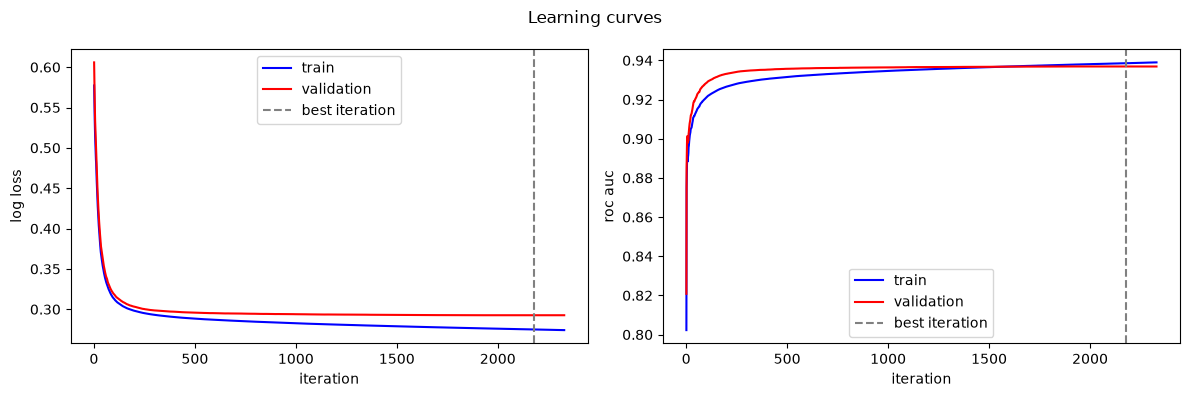

                 name   rows  features  best_iteration  seconds  train_loss  valid_loss    gap  valid_auc  on_books_roc_auc  on_books_brier  on_books_ece  near_roc_auc  near_brier  future_roc_auc  future_brier  on_books_share_above_0.99
family lightgbm tuned 630664        49            2179      343     0.27498     0.29249 0.0175    0.93693            0.9126          0.0898        0.0134        0.8706      0.2885          0.8941        0.1851                        0.0
      family logistic 630664        49               0       53     0.35807     0.36158 0.0035    0.90194            0.8849          0.1033        0.0138        0.8478      0.2019          0.8646        0.1523                        0.0


In [56]:
family_raw = {}
family_valid = {}
if "families" in cache:
    results = results + cache["families"]["results"]
    curves.update(cache["families"]["curves"])
    family_raw = {m: {k: np.array(v) for k, v in d.items()} for m, d in cache["families"]["raw"].items()}
    family_valid = {m: np.array(v) for m, v in cache["families"]["valid"].items()}
    families_todo = []
else:
    families_todo = [("logistic", fit_logistic, "scaled")] if quick else [("catboost", fit_catboost, "plain"), ("logistic", fit_logistic, "scaled"), ("extra trees", fit_extra_trees, "plain"), ("neural network", fit_mlp, "scaled")]
stage_rows = []
stage_curves = {}
if families_todo:
    row, lgbm_model, curve, preds, cal = run_setup("family lightgbm tuned", search_data, best_params)
    results.append(row)
    curves[row["name"]] = curve
    stage_rows.append(row)
    stage_curves[row["name"]] = curve
    family_raw["lightgbm"] = {label: lgbm_model.predict(x, num_iteration=lgbm_model.best_iteration) for label, x in search_data["tests"].items()}
    family_valid["lightgbm"] = lgbm_model.predict(search_data["x_valid"], num_iteration=lgbm_model.best_iteration)
    print(json.dumps(row))
    scaled_data = prepare(windows[best_window], final_cols, 1, cap=cap_choice[0], cap_mode=cap_choice[1], scaling="standard")
    for label, fit, kind in families_todo:
        data = scaled_data if kind == "scaled" else search_data
        row, model, preds, cal, predict = run_other("family " + label, data, fit)
        results.append(row)
        stage_rows.append(row)
        family_raw[label] = {name: predict(x) for name, x in data["tests"].items()}
        family_valid[label] = predict(data["x_valid"])
        print(json.dumps(row))
        del model
    del scaled_data
    cache_save("families", {"results": stage_rows, "curves": stage_curves, "raw": {m: {k: v.tolist() for k, v in d.items()} for m, d in family_raw.items()}, "valid": {m: v.tolist() for m, v in family_valid.items()}})
for name in stage_curves if stage_curves else [n for n in curves if n.startswith("family")]:
    plot_learning_curves(curves[name])
print(results_table([r for r in results if r["name"].startswith("family")]).to_string(index=False))

In [57]:
family_table = results_table([r for r in results if r["name"].startswith("family")]).sort_values("valid_auc", ascending=False)
members = [n.replace("family ", "").replace("lightgbm tuned", "lightgbm") for n in family_table["name"].head(2 if quick else 3)]
meta_x = np.column_stack([family_valid[m] for m in members])
meta = LogisticRegression(max_iter=1000)
meta.fit(np.log(np.clip(meta_x, 1e-6, 1 - 1e-6) / (1 - np.clip(meta_x, 1e-6, 1 - 1e-6))), search_data["y_valid"])
row = {"name": "stack of " + ", ".join(members), "rows": search_data["rows"], "features": len(final_cols), "best_iteration": 0, "seconds": 0, "train_loss": None, "valid_loss": None, "gap": None, "valid_auc": round(float(roc_auc_score(search_data["y_valid"], meta.predict_proba(np.log(np.clip(meta_x, 1e-6, 1 - 1e-6) / (1 - np.clip(meta_x, 1e-6, 1 - 1e-6))))[:, 1])), 5)}
for label in test_sets:
    stack_x = np.column_stack([family_raw[m][label] for m in members])
    p = np.clip(meta.predict_proba(np.log(np.clip(stack_x, 1e-6, 1 - 1e-6) / (1 - np.clip(stack_x, 1e-6, 1 - 1e-6))))[:, 1], clip_low, clip_high)
    m = evaluate(p, test_sets[label]["is_canceled"].values)
    for key in ["roc_auc", "brier", "ece", "share_above_0.99"]:
        row[label + "_" + key] = m[key]
results.append(row)
print("stack members " + ", ".join(members) + ", meta weights " + json.dumps([round(float(w), 3) for w in meta.coef_[0]]))
print(json.dumps(row))

stack members lightgbm, logistic, meta weights [1.02, -0.0]
{"name": "stack of lightgbm, logistic", "rows": 630664, "features": 49, "best_iteration": 0, "seconds": 0, "train_loss": null, "valid_loss": null, "gap": null, "valid_auc": 0.93693, "on_books_roc_auc": 0.9134, "on_books_brier": 0.0896, "on_books_ece": 0.0137, "on_books_share_above_0.99": 0.0, "near_roc_auc": 0.8725, "near_brier": 0.2912, "near_ece": 0.3347, "near_share_above_0.99": 0.0, "future_roc_auc": 0.8953, "future_brier": 0.1866, "future_ece": 0.1901, "future_share_above_0.99": 0.0}


#### Calibration
* isotonic with clipped output against platt scaling, both fit on validation, judged on the test sets

In [58]:
for method in ["isotonic", "platt"]:
    row, model, curve, preds, cal = run_setup("calibration " + method, search_data, best_params, calibration=method)
    results.append(row)
    print(json.dumps(row))
print(results_table([r for r in results if r["name"].startswith("calibration")]).to_string(index=False))

{"name": "calibration isotonic", "rows": 630664, "features": 49, "best_iteration": 2179, "seconds": 343, "train_loss": 0.27498, "valid_loss": 0.29249, "gap": 0.0175, "valid_auc": 0.93693, "on_books_roc_auc": 0.9126, "on_books_brier": 0.0898, "on_books_ece": 0.0134, "on_books_share_above_0.99": 0.0, "near_roc_auc": 0.8706, "near_brier": 0.2885, "near_ece": 0.3342, "near_share_above_0.99": 0.0, "future_roc_auc": 0.8941, "future_brier": 0.1851, "future_ece": 0.1894, "future_share_above_0.99": 0.0}


{"name": "calibration platt", "rows": 630664, "features": 49, "best_iteration": 2179, "seconds": 338, "train_loss": 0.27498, "valid_loss": 0.29249, "gap": 0.0175, "valid_auc": 0.93693, "on_books_roc_auc": 0.9134, "on_books_brier": 0.0896, "on_books_ece": 0.0137, "on_books_share_above_0.99": 0.0, "near_roc_auc": 0.8725, "near_brier": 0.2912, "near_ece": 0.3348, "near_share_above_0.99": 0.0, "future_roc_auc": 0.8953, "future_brier": 0.1866, "future_ece": 0.1901, "future_share_above_0.99": 0.0}
                name   rows  features  best_iteration  seconds  train_loss  valid_loss    gap  valid_auc  on_books_roc_auc  on_books_brier  on_books_ece  near_roc_auc  near_brier  future_roc_auc  future_brier  on_books_share_above_0.99
calibration isotonic 630664        49            2179      343     0.27498     0.29249 0.0175    0.93693            0.9126          0.0898        0.0134        0.8706      0.2885          0.8941        0.1851                        0.0
   calibration platt 630664    

#### Results and the chosen setup
* every row with its validation log loss, gap and auc and the test metrics; the chosen setup follows the reliability rule

In [59]:
pd.set_option("display.width", 260)
table = results_table(results)
print(table.to_string(index=False))
final = {"window": best_window, "outliers": best_cap, "features": final_cols, "params": best_config, "calibration": "isotonic clipped to " + str(clip_low) + " to " + str(clip_high), "snapshot": str(snapshot.date())}
print("chosen setup: " + json.dumps({k: v for k, v in final.items() if k != "features"}))
print("features: " + ", ".join(final_cols))
out = {"results": results, "final": final, "search": [{"name": r["name"], "valid_auc": r["valid_auc"], "gap": r["gap"], "config": r["config"]} for r in search_rows], "stepwise_gbdt": selected, "stepwise_logit": logit_selected, "curves": {k: curves[k] for k in curves if k.startswith("family lightgbm") or k.startswith("v1 recipe")}, "generated_at": datetime.datetime.now(datetime.timezone.utc).isoformat()}
with open(os.path.join(MODELS_DIR, "experiments_cancellation_synth.json"), "w") as f:
    json.dump(out, f, indent=1, default=str)
print("saved " + os.path.join(MODELS_DIR, "experiments_cancellation_synth.json"))

                                                           name   rows  features  best_iteration  seconds  train_loss  valid_loss     gap  valid_auc  on_books_roc_auc  on_books_brier  on_books_ece  near_roc_auc  near_brier  future_roc_auc  future_brier  on_books_share_above_0.99
 v1 recipe, first feature set, all history, one landmark sample 630664        51             796      181     0.24928     0.29165  0.0424    0.93737            0.9121          0.0897        0.0185        0.8684      0.2841          0.8974        0.1809                        0.0
v1 recipe, second feature set, all history, one landmark sample 630664        75            1162      259     0.23122     0.29216  0.0609    0.93711            0.9113          0.0904        0.0133        0.8683      0.2797          0.8951        0.1785                        0.0
                                                     window all 630664        75            1432      243     0.26909     0.29241  0.0233    0.93696            